In [1]:
import sys
import csv
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm


# Project-specific paths — update these to match your local setup
XS_LIB_PATH   = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron'
SRC_PATH       = '/home/paule/open_mc_projects/MC-1D_DT/structured_code'
VECTFIT_DIR    = Path(SRC_PATH) / 'src/vectfit_data'
OPENMC_FILE    = Path(SRC_PATH) / 'validation/method_validation/openmc_results_point.csv'

sys.path.extend([XS_LIB_PATH, SRC_PATH])

import geometry_constructor
from src.geometry_classes import Geometry, Source, Material
import src.parallel as parallel
import src.export_print_csv as xp_sim
import src.illustration

['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT/structured_code', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
geometry, source = geometry_constructor.create_geometry_PWR_fresh_fuel(
    maj_mat_method= "maj_mat",
    maj_xs_method = "sqrtT_E",
    access_method= "reconr",
    mode= "analysis",
    neutron_nbr= 1000
)

[Material] Processing nuclide pair: H1 (Density: 4.75e+22)
[Material] Processing nuclide pair: O16 (Density: 2.37e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: H1 (Density: 4.75e+22)
[Material] Processing nuclide pair: O16 (Density: 2.37e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: H1 (Density: 4.75e+22)
[Material] Processing nuclide pair: O16 (Density: 2.37e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: U235 (Density: 2.66e+20)
[Material] Processing nuclide pair: U238 (Density: 2.60e+22)
[Material] Processing nuclide pair: O16 (Density: 4.64e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: U235 (Density: 2.66e+20)
[Material] Processing nuclide pair: U238 (Density: 2.60e+22)
[Material] Processing nuclide p

  PERFORMANCE SUMMARY
  Metric                               Wall (s)     CPU (s)
----------------------------------------------------------------
  Preprocessing                         11.5273      2.9509
  Run-source (transport only)               nan         nan
  Total  (preprocessing + run)              nan         nan
----------------------------------------------------------------
    ↳ Majorant XS evaluations            0.0000      0.0000
    ↳ Local XS evaluations               0.0000      0.0000
----------------------------------------------------------------
  CPU efficiency (run-source)               nan    [cpu/wall, per-process]
  Neutrons / second                         0.0    [based on run-source time]
----------------------------------------------------------------
  Neutrons simulated                          0
  Majorant updates                            0
  XS evaluations                              0
  Real collisions                             0
  Virtual (re

Text(0.5, 1.0, 'Majorant XS Grid for RECONR Access Method')

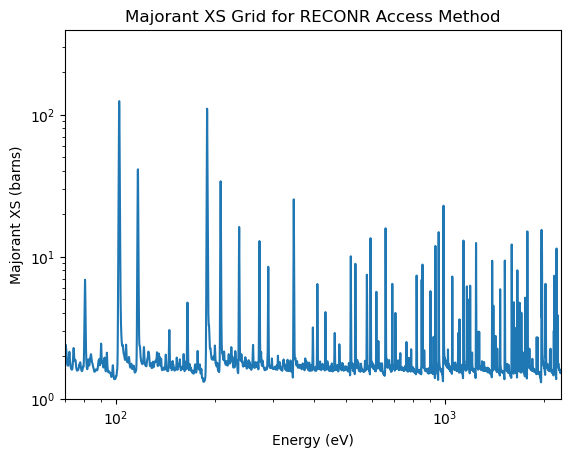

In [3]:
print(geometry.perf.summary())

plt.plot(geometry.reconr_e_grid, geometry.reconr_maj_xs_grid)
plt.xlim(70, geometry.reconr_e_grid[-1])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Majorant XS (barns)")
plt.title("Majorant XS Grid for RECONR Access Method")  



/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/illustration.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


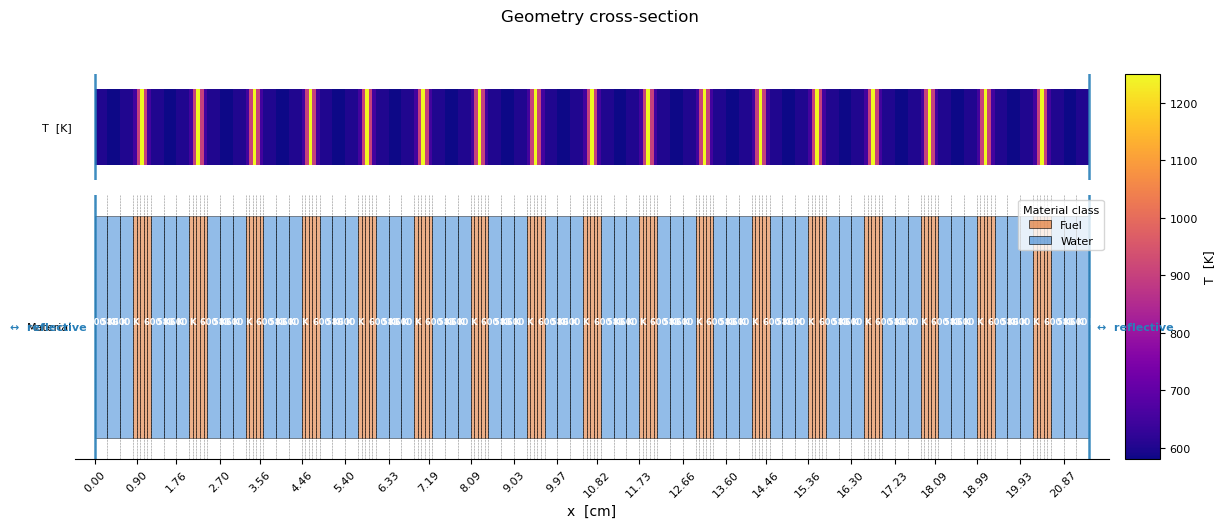

(<Figure size 1400x500 with 3 Axes>,
 <Axes: xlabel='x  [cm]', ylabel='Material'>)

In [4]:


src.illustration.draw(geometry)

/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/geometry_plot.py:396: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  GEOMETRY SUMMARY
  Span        : 0.0000 → 21.4173 cm   (Δ = 21.4173 cm)
  Regions     : 139
  BC left     : reflective
  BC right    : reflective

────────────────────────────────────────────────────────────────────────
  CLASS : FUEL
  Regions       : 85
  Total width   : 6.5200 cm
  T range       : 650 – 1250 K

  Unique compositions : 17  (out of 85 regions — sub-slabs with same composition grouped)

    ┌─ fuel_rod01_sub1  ×5 regions   T ∈ {650, 900, 1250} K
    │   Nuclide         N [at/cm³]    at. frac    wt. frac
    │   ──────────  ──────────────  ──────────  ──────────
    │   O16             4.6389e-02      0.6381      0.1059
    │   U238            2.6047e-02      0.3583      0.8851
    │   U235            2.6646e-04      0.0037      0.0089
    │   ──────────  ──────────────  ──────────  ──────────
    │   TOTAL           7.2702e-02      1.0000      1.0000
    └──────────────────────────────────────────────────────────────────

    ┌─ fuel_rod02_sub1  ×5 regions   T ∈ {650

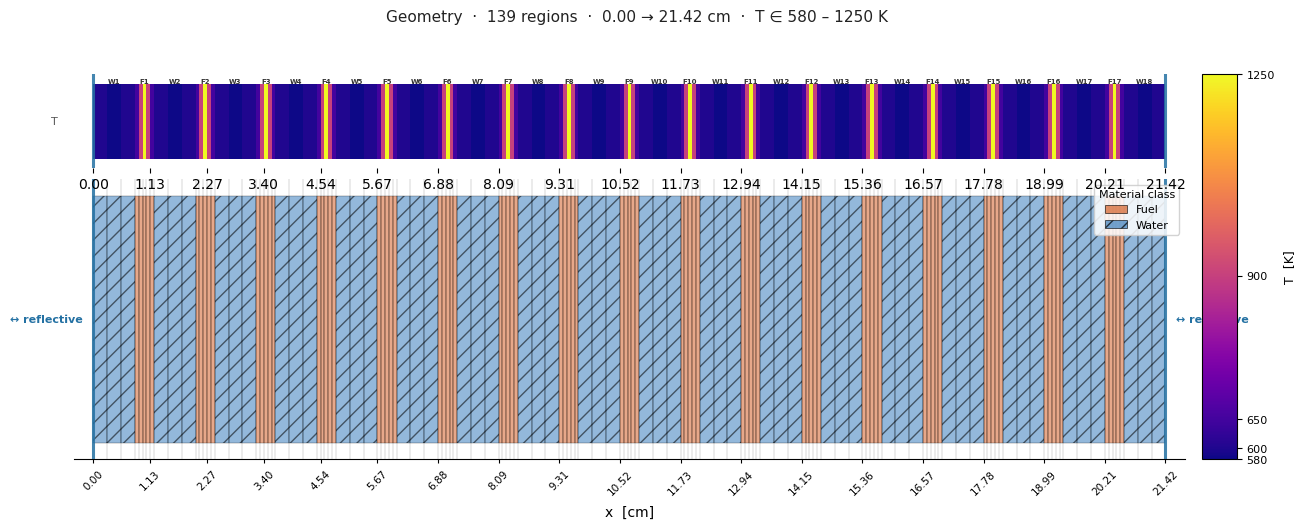

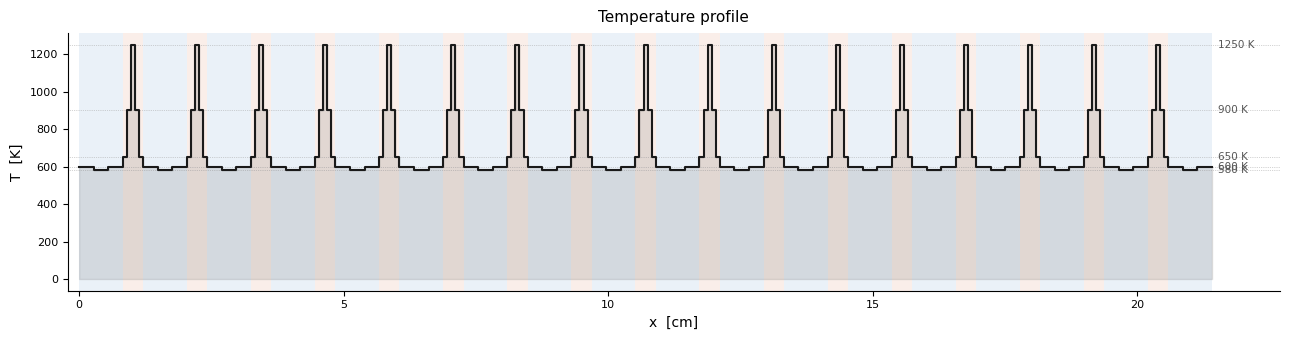

In [5]:
import src.geometry_plot as gp

# 1 — standalone functions
gp.draw(geometry)
gp.draw_temperature_profile(geometry)
gp.print_summary(geometry)




/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/source_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/source_plot.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


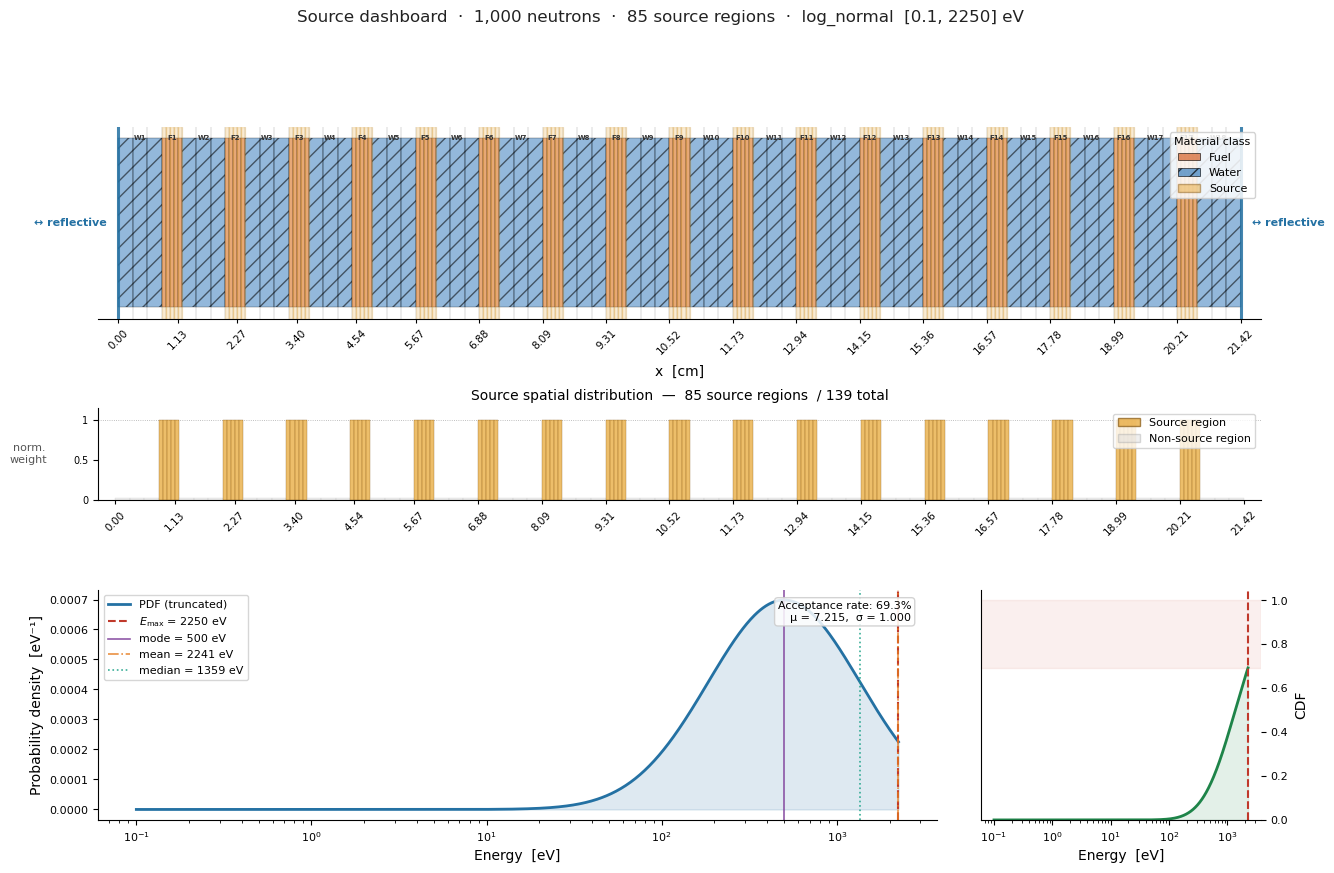

[SourcePlotter] Saved → source_dashboard.png


(<Figure size 1400x250 with 1 Axes>,
 <Axes: title={'center': 'Source spatial distribution  —  85 source regions  / 139 total'}, xlabel='x  [cm]', ylabel='norm.\nweight'>)

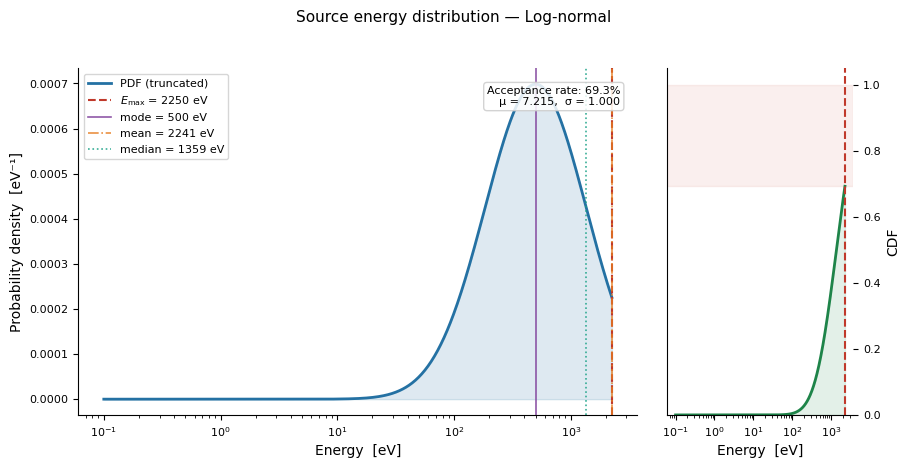

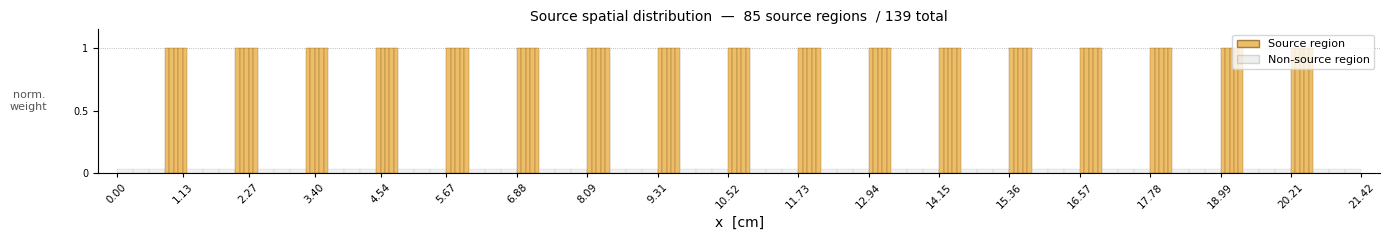

In [6]:
from src.source_plot import SourcePlotter, draw_source, draw_energy, draw_spatial

# full dashboard
p = SourcePlotter(source, geometry)
p.draw()
p.save("source_dashboard.png", dpi=200)

# individual panels
draw_energy(source)
draw_spatial(source, geometry)

In [9]:
source.neutron_nbr = 1000

batches = geometry.run_batch(source, n_batches=20, mode= "parallel")



 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker stopped.


In [8]:

xp_sim.export_cross_batch_stats(
                                batch_stats=batches,
                                geom=geometry,
                                print_to_console=True,
                                save_csv=True,
                                output_dir=None
                            )



  PERFORMANCE SUMMARY
  Metric                               Wall (s)     CPU (s)
----------------------------------------------------------------
  Preprocessing                         11.5273      2.9509
  Run-source (transport only)               nan         nan
  Total  (preprocessing + run)              nan         nan
----------------------------------------------------------------
    ↳ Majorant XS evaluations            0.0000      0.0000
    ↳ Local XS evaluations               0.0000      0.0000
----------------------------------------------------------------
  CPU efficiency (run-source)               nan    [cpu/wall, per-process]
  Neutrons / second                         0.0    [based on run-source time]
----------------------------------------------------------------
  Neutrons simulated                          0
  Majorant updates                            0
  XS evaluations                              0
  Real collisions                             0
  Virtual (re